# Module 04 — Validation Strategy

Cross-validation is where most of the real intellectual work in applied ML
happens, and where most of the real errors are made. The algorithm you choose
might move your metric by a point or two. **A wrong validation scheme can move
it by twenty, in the wrong direction, invisibly.**

The central question of this module is not "how do I call `cross_val_score`".
It is: *what does my validation split have to look like for the number it
produces to be an honest estimate of what happens when this model meets data
it has never seen?*

### Learning objectives

1. Choose the correct splitter from the structure of the data, not by habit.
2. Recognise group leakage and temporal leakage, and measure both.
3. Use `cross_validate` and `cross_val_predict` for what each is actually for.
4. Understand nested CV and when the extra cost is justified.
5. Read learning curves and validation curves as diagnostics.
6. Quantify the uncertainty in a CV estimate, so you stop over-reading small
   differences.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_card_fraud, load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

## 1. The splitter decision tree

Answer these in order. The first "yes" decides it.

```
Are observations ordered in time, and will you predict the future?
    └── yes → TimeSeriesSplit  (or a manual expanding-window split)

Do multiple rows belong to the same entity (customer, card, patient, device)?
    └── yes → GroupKFold  /  StratifiedGroupKFold  /  GroupShuffleSplit

Is the target imbalanced or multiclass?
    └── yes → StratifiedKFold

Otherwise
    └── KFold(shuffle=True, random_state=…)
```

Two of those branches can apply at once (time *and* groups), and sklearn has
no built-in splitter for the intersection. You write it yourself — Exercise
4.5.

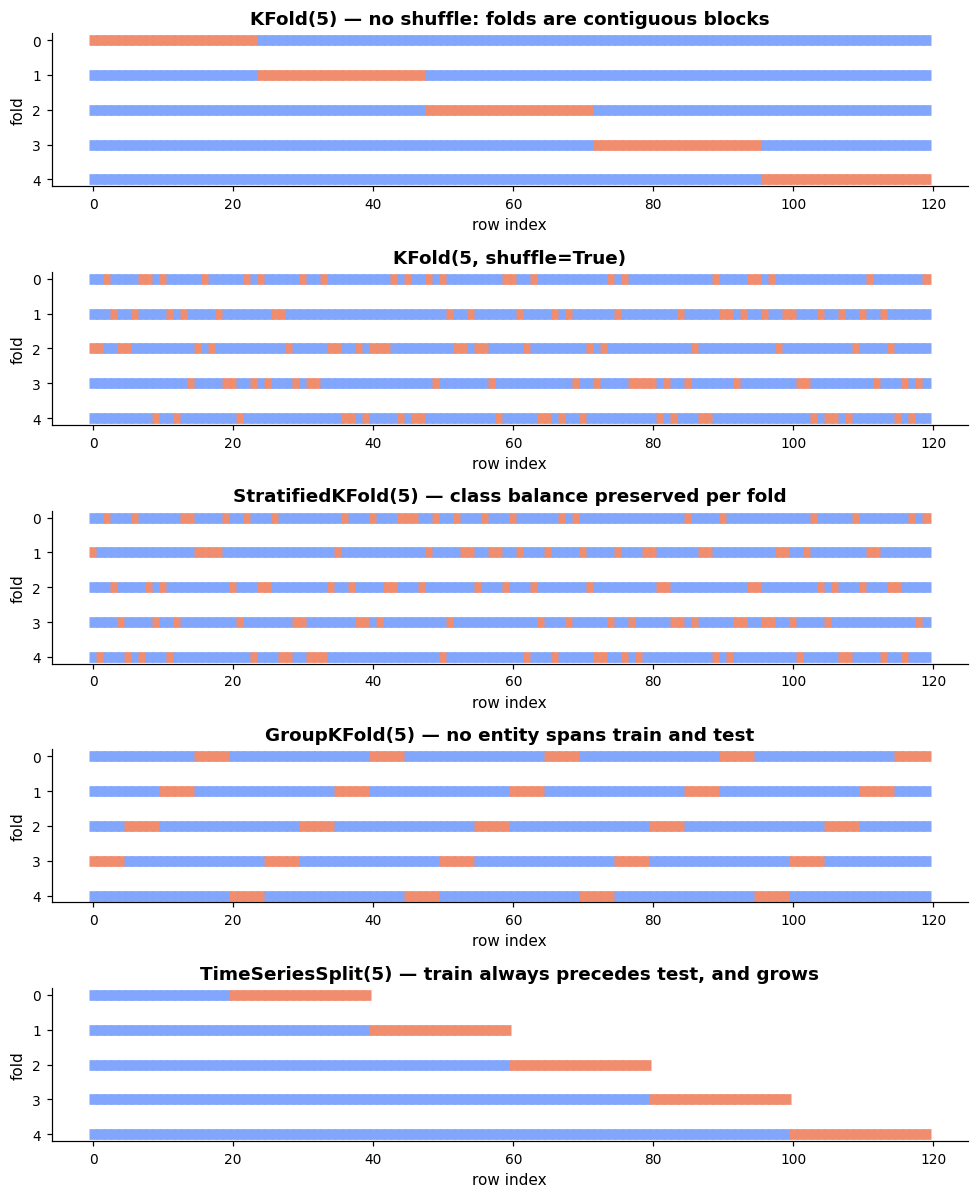

In [2]:
from sklearn.model_selection import (
    GroupKFold,
    KFold,
    ShuffleSplit,
    StratifiedGroupKFold,
    StratifiedKFold,
    TimeSeriesSplit,
)


def plot_splitter(cv, X, y=None, groups=None, ax=None, title=""):
    """Visualise which rows land in train vs test for each fold."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 2.4))
    n = len(X)
    for i, (tr, te) in enumerate(cv.split(X, y, groups)):
        indices = np.full(n, np.nan)
        indices[tr] = 0
        indices[te] = 1
        ax.scatter(range(n), np.full(n, i), c=indices, marker="_", lw=7, cmap="coolwarm", vmin=-0.4, vmax=1.4)
    ax.set(yticks=range(cv.get_n_splits(X, y, groups)), ylabel="fold", xlabel="row index", title=title)
    ax.invert_yaxis()
    ax.grid(False)
    return ax


n = 120
X_demo = np.arange(n).reshape(-1, 1)
y_demo = np.r_[np.zeros(96), np.ones(24)].astype(int)   # 20% positive, all at the end
groups_demo = np.repeat(np.arange(24), 5)               # 24 entities × 5 rows each

fig, axes = plt.subplots(5, 1, figsize=(9, 11))
plot_splitter(KFold(5), X_demo, ax=axes[0], title="KFold(5) — no shuffle: folds are contiguous blocks")
plot_splitter(KFold(5, shuffle=True, random_state=0), X_demo, ax=axes[1], title="KFold(5, shuffle=True)")
plot_splitter(StratifiedKFold(5, shuffle=True, random_state=0), X_demo, y_demo, ax=axes[2], title="StratifiedKFold(5) — class balance preserved per fold")
plot_splitter(GroupKFold(5), X_demo, y_demo, groups_demo, ax=axes[3], title="GroupKFold(5) — no entity spans train and test")
plot_splitter(TimeSeriesSplit(5), X_demo, ax=axes[4], title="TimeSeriesSplit(5) — train always precedes test, and grows")
plt.tight_layout()

Look hard at the first panel. **`KFold` does not shuffle by default.** If your
dataframe arrived sorted by date, by customer segment, or by target — and
exported tables very often are — plain `KFold` gives you five folds that are
each a different slice of the population. People discover this the hard way.

## 2. Group leakage, measured

The `card_fraud` data has ~9,000 cards and 60,000 transactions, so each card
appears ~7 times. If a card's transactions are split across train and test,
the model can memorise the card rather than learn fraud.

In [3]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

fraud = load_card_fraud()
print(f"{len(fraud):,} transactions, {fraud.card_id.nunique():,} cards, "
      f"{fraud.is_fraud.mean():.3%} fraud rate")

# We deliberately include card_id as a feature -- exactly the mistake we want
# the validation scheme to catch.
feat = fraud.drop(columns=["is_fraud", "timestamp"])
target = fraud["is_fraud"]
groups = fraud["card_id"]

prep = ColumnTransformer(
    [("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
      make_column_selector(dtype_include=["object", "string", "category"]))],
    remainder="passthrough",
)
model = Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=200))])

naive = cross_val_score(model, feat, target, cv=StratifiedKFold(5, shuffle=True, random_state=0),
                        scoring="average_precision", n_jobs=-1)
grouped = cross_val_score(model, feat, target, groups=groups, cv=StratifiedGroupKFold(5, shuffle=True, random_state=0),
                          scoring="average_precision", n_jobs=-1)

print(f"\nStratifiedKFold      AP = {naive.mean():.4f} ± {naive.std():.4f}")
print(f"StratifiedGroupKFold AP = {grouped.mean():.4f} ± {grouped.std():.4f}")
print(f"\ninflation from letting cards span folds: {(naive.mean() / grouped.mean() - 1):+.1%}")

60,000 transactions, 8,982 cards, 0.547% fraud rate



StratifiedKFold      AP = 0.1614 ± 0.0290
StratifiedGroupKFold AP = 0.1759 ± 0.0506

inflation from letting cards span folds: -8.2%


> 💼 **Consulting lens.** Group leakage is the most under-diagnosed failure in
> production ML, because the model genuinely does perform as advertised on
> entities it has already seen — and then meets a new customer. Whenever a
> model is scored on *new* entities in production, the validation must be
> grouped. The question to ask a team is simply: **"at inference time, will
> you have seen this entity before?"**

## 3. Temporal validation

The credit data spans 36 months and contains a genuine macro shock in the
final year. A random split lets the model train on 2024 and test on 2022,
which is not a thing that can happen in production.

In [4]:
credit = load_credit_risk()
credit = credit.sort_values("application_month").reset_index(drop=True)
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])

print("default rate by year:")
print(credit.groupby(credit.application_month.str[:4])["default"].agg(["mean", "size"]).round(4).to_string())

default rate by year:
                     mean  size
application_month              
2022               0.1107  2727
2023               0.1175  3923
2024               0.1548  5350


In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

prep_credit = ColumnTransformer(
    [
        ("num", Pipeline([("i", SimpleImputer(strategy="median", add_indicator=True)), ("s", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False),
         make_column_selector(dtype_include=["object", "string", "category"])),
    ]
)
credit_model = Pipeline([("prep", prep_credit), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=250, learning_rate=0.06))])

random_cv = cross_val_score(credit_model, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="roc_auc", n_jobs=-1)
time_cv = cross_val_score(credit_model, X, y, cv=TimeSeriesSplit(5), scoring="roc_auc", n_jobs=-1)

print(f"random  5-fold : {random_cv.mean():.4f} ± {random_cv.std():.4f}")
print(f"time    5-fold : {time_cv.mean():.4f} ± {time_cv.std():.4f}")
print(f"\nper-fold, chronological: {time_cv.round(4)}")

random  5-fold : 0.7490 ± 0.0182
time    5-fold : 0.7369 ± 0.0311

per-fold, chronological: [0.6867 0.7398 0.7843 0.7311 0.7428]


The per-fold time-series numbers are the interesting output. They are not
noise around a mean — they are a **time series of model performance**, and a
downward trend in them is an early warning that the relationship you are
modelling is not stable. That is information a random 5-fold cannot give you
at any price.

,auc,default_rate,n
application_month,,,
2023-07,0.702647,0.140719,334.0
2023-08,0.756414,0.116279,344.0
2023-09,0.675707,0.111111,351.0
2023-10,0.699186,0.086111,360.0
2023-11,0.753903,0.127027,370.0


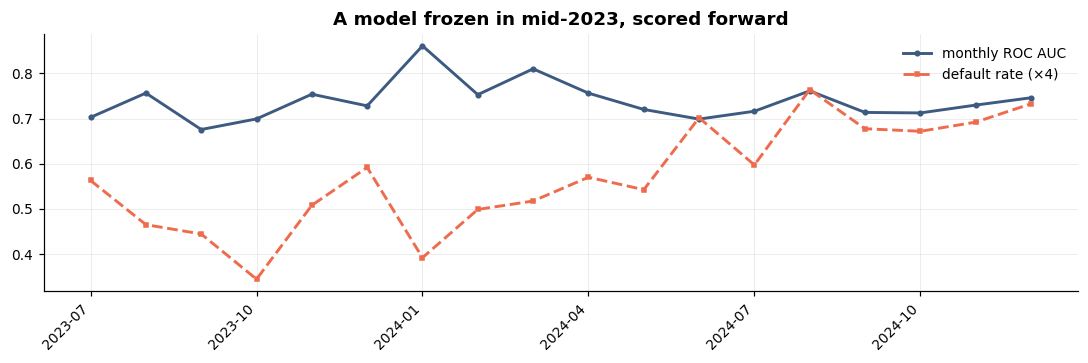

In [6]:
# Made explicit: train on a fixed window, score each subsequent month.
train_mask = credit.application_month < "2023-07"
model_fixed = credit_model.fit(X[train_mask], y[train_mask])

from sklearn.metrics import roc_auc_score

monthly = (
    credit[~train_mask]
    .assign(score=model_fixed.predict_proba(X[~train_mask])[:, 1])
    .groupby("application_month")
    .apply(lambda g: pd.Series({"auc": roc_auc_score(g["default"], g["score"]) if g["default"].nunique() > 1 else np.nan,
                                "default_rate": g["default"].mean(),
                                "n": len(g)}), include_groups=False)
)

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(monthly.index, monthly["auc"], marker="o", ms=3, label="monthly ROC AUC")
ax.plot(monthly.index, monthly["default_rate"] * 4, marker="s", ms=3, ls="--", label="default rate (×4)")
ax.set_xticks(monthly.index[::3])
ax.set_title("A model frozen in mid-2023, scored forward")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
monthly.head()

## 4. `cross_val_score` vs `cross_validate` vs `cross_val_predict`

| Function | Returns | Use for |
|---|---|---|
| `cross_val_score` | one array of scores | a single number, quickly |
| `cross_validate` | dict: multiple metrics, timings, optionally train scores and the fitted estimators | **almost always this one** |
| `cross_val_predict` | one out-of-fold prediction per row | diagnostics, calibration, stacking |

`cross_validate` costs nothing extra and tells you far more. `return_train_score`
in particular converts "my model scores 0.76" into "my model scores 0.76 in
validation and 0.97 in training", which is a completely different conversation.

In [7]:
from sklearn.model_selection import cross_validate

res = cross_validate(
    credit_model, X, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=0),
    scoring=["roc_auc", "average_precision", "neg_brier_score"],
    return_train_score=True,
    return_estimator=True,
    n_jobs=-1,
)
pd.DataFrame({k: v for k, v in res.items() if k != "estimator"}).round(4)

,fit_time,score_time,test_roc_auc,train_roc_auc,test_average_precision,train_average_precision,test_neg_brier_score,train_neg_brier_score
0,0.7930,0.0538,0.7691,0.9909,0.4435,0.9461,-0.0946,-0.0431
1,0.9733,0.0634,0.7219,0.9903,0.3558,0.9492,-0.1041,-0.0415
2,0.8047,0.0523,0.7379,0.9907,0.3907,0.9446,-0.1011,-0.0424
3,1.0093,0.0660,0.7474,0.9903,0.3577,0.9438,-0.1030,-0.0424
4,0.7663,0.0578,0.7686,0.9885,0.4234,0.9391,-0.0968,-0.0436


In [8]:
print("train vs test AUC gap:", round(res["train_roc_auc"].mean() - res["test_roc_auc"].mean(), 4))
print("return_estimator gives you the 5 fitted pipelines:", type(res["estimator"][0]).__name__)

train vs test AUC gap: 0.2411
return_estimator gives you the 5 fitted pipelines: Pipeline


### `cross_val_predict` — and the thing it is *not* for

It gives every row a prediction made by a model that did not train on it.
Excellent for calibration plots, error analysis and stacking.

**It is not a way to compute a score.** `roc_auc_score(y, cross_val_predict(...))`
is subtly wrong: the predictions come from five *different* models, so the
resulting ranking mixes five different score scales. Use it for diagnosis, not
for measurement.

In [9]:
from sklearn.model_selection import cross_val_predict

oof = cross_val_predict(credit_model, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0),
                        method="predict_proba", n_jobs=-1)[:, 1]

proper = res["test_roc_auc"].mean()
pooled = roc_auc_score(y, oof)
print(f"mean of per-fold AUCs (correct)      : {proper:.4f}")
print(f"AUC of pooled OOF predictions (not)  : {pooled:.4f}")
print("\nThey are close here, which is why the mistake survives. They need not be.")

mean of per-fold AUCs (correct)      : 0.7490
AUC of pooled OOF predictions (not)  : 0.7486

They are close here, which is why the mistake survives. They need not be.


,mean_pred,actual,n
decile,,,
0,0.0047,0.0192,1200
1,0.0148,0.0492,1200
2,0.0258,0.0642,1200
3,0.0397,0.0742,1200
4,0.0555,0.0808,1200
5,0.0763,0.1050,1200
6,0.1056,0.1242,1200
7,0.1469,0.1483,1200
8,0.2247,0.2125,1200


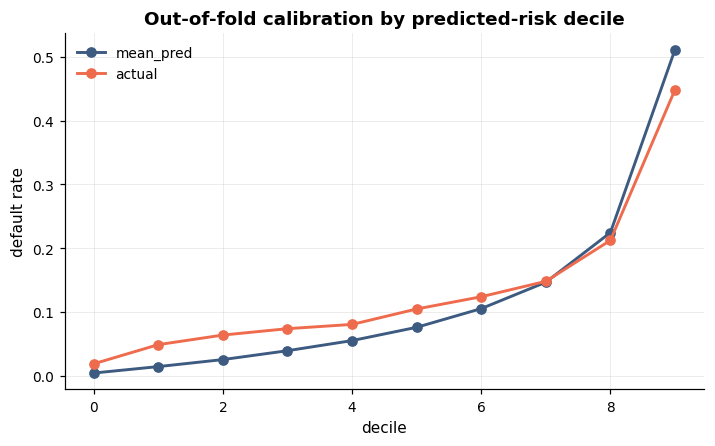

In [10]:
# What cross_val_predict IS for: seeing where the model is wrong.
err = pd.DataFrame({"oof": oof, "y": y.to_numpy(), "score": credit["credit_score"].to_numpy()})
err["decile"] = pd.qcut(err["oof"], 10, labels=False, duplicates="drop")
lift = err.groupby("decile").agg(mean_pred=("oof", "mean"), actual=("y", "mean"), n=("y", "size"))
ax = lift[["mean_pred", "actual"]].plot(marker="o")
ax.set_title("Out-of-fold calibration by predicted-risk decile")
ax.set_ylabel("default rate")
lift.round(4)

## 5. How uncertain is a CV estimate?

A single 5-fold CV gives you five numbers. Their standard deviation
understates the true uncertainty, because the folds share training data and
are therefore correlated. `RepeatedStratifiedKFold` gives a better picture.

30 scores: mean 0.7481, std 0.0135
range     : 0.7216 — 0.7702   (spread of 0.0486)

95% interval for the mean: 0.7433 — 0.7529


Text(0.5, 0, 'ROC AUC')

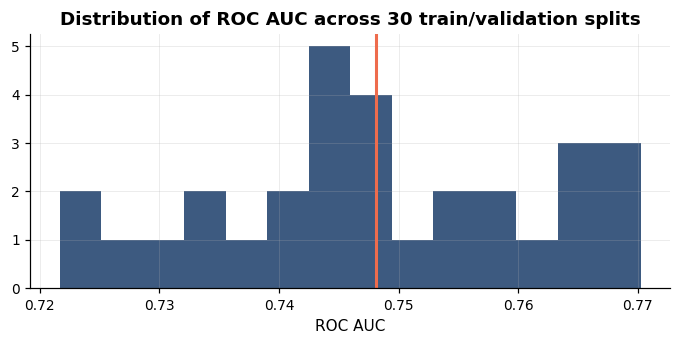

In [11]:
from sklearn.model_selection import RepeatedStratifiedKFold

rep = cross_val_score(
    credit_model, X, y,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=0),
    scoring="roc_auc", n_jobs=-1,
)
print(f"30 scores: mean {rep.mean():.4f}, std {rep.std():.4f}")
print(f"range     : {rep.min():.4f} — {rep.max():.4f}   (spread of {rep.max() - rep.min():.4f})")
print(f"\n95% interval for the mean: "
      f"{rep.mean() - 1.96 * rep.std() / np.sqrt(len(rep)):.4f} — {rep.mean() + 1.96 * rep.std() / np.sqrt(len(rep)):.4f}")

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.hist(rep, bins=14, color="#3d5a80")
ax.axvline(rep.mean(), color="#ee6c4d", lw=2)
ax.set_title("Distribution of ROC AUC across 30 train/validation splits")
ax.set_xlabel("ROC AUC")

That spread is your **noise floor**. Any model comparison whose difference is
smaller than it is not a result. Writing "Model B beat Model A, 0.7612 to
0.7589" when the noise floor is ±0.01 is a claim you cannot support, and it is
the single most common overreach in model-selection write-ups.

The disciplined habit: report `mean ± std` and state the number of splits, and
refuse to pick a winner inside the interval — pick on simplicity, latency or
explainability instead.

## 6. Nested cross-validation

If you tune hyperparameters using CV and then report that same CV score, the
score is optimistically biased: you selected the configuration that happened
to do best on those folds. Nested CV separates the two jobs.

- **Inner loop** — selects hyperparameters.
- **Outer loop** — estimates the performance of the *whole procedure*,
  including the selection.

The cost is `n_outer × n_inner × n_candidates` fits. The benefit is an unbiased
number. Whether that is worth it depends on how much your decision rests on
the number.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

small = Pipeline([("prep", prep_credit), ("clf", LogisticRegression(max_iter=3000))])
param_grid = {"clf__C": [0.01, 0.1, 1.0, 10.0]}

inner = StratifiedKFold(3, shuffle=True, random_state=1)
outer = StratifiedKFold(5, shuffle=True, random_state=0)

search = GridSearchCV(small, param_grid, cv=inner, scoring="roc_auc", n_jobs=-1)

# Non-nested: fit the search on everything, report its best score.
search.fit(X, y)
non_nested = search.best_score_

# Nested: the search is the estimator being cross-validated.
nested = cross_val_score(search, X, y, cv=outer, scoring="roc_auc", n_jobs=-1)

print(f"non-nested (optimistic) : {non_nested:.4f}")
print(f"nested     (honest)     : {nested.mean():.4f} ± {nested.std():.4f}")
print(f"optimism                : {non_nested - nested.mean():+.4f}")

non-nested (optimistic) : 0.7767
nested     (honest)     : 0.7764 ± 0.0138
optimism                : +0.0003


The optimism here is small because the grid is small (4 candidates). It grows
with the size of the search: a 500-candidate random search over a noisy metric
will produce a `best_score_` that is meaningfully inflated. **The bigger your
search, the more you need nested CV — or a genuinely untouched holdout.**

In practice, most teams use the cheaper alternative: a holdout set that is
split off once, never looked at during development, and scored exactly once at
the end. That is a fine substitute *if the discipline holds*, and the
discipline usually does not.

## 7. Learning curves and validation curves

Two diagnostics that answer two different questions.

- **Learning curve** — score vs *training-set size*. Answers: *would more data
  help?*
- **Validation curve** — score vs *one hyperparameter*. Answers: *am I over-
  or under-fitting, and in which direction should I move?*

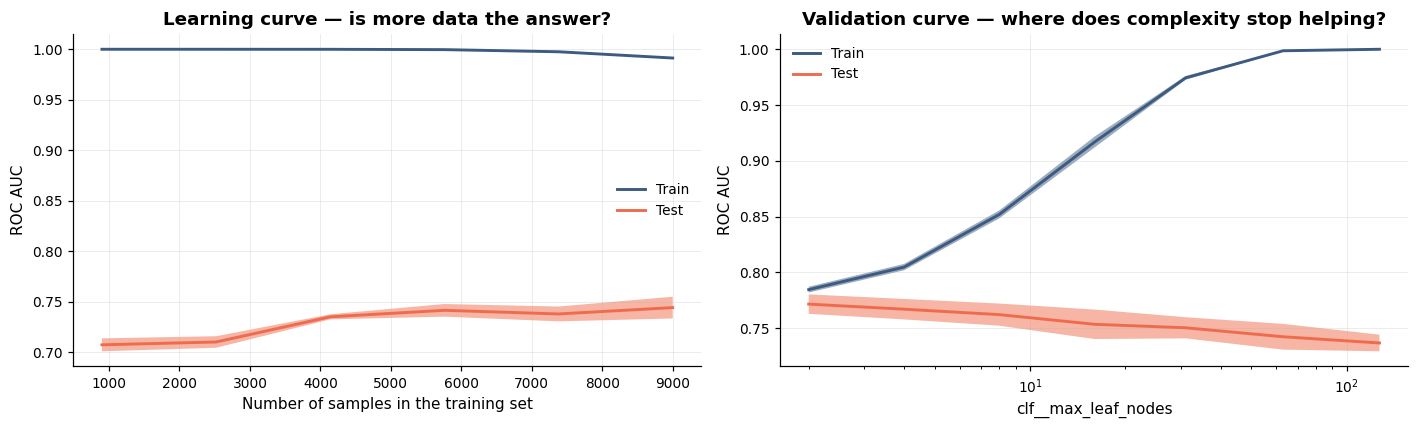

In [13]:
from sklearn.model_selection import LearningCurveDisplay, ValidationCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

LearningCurveDisplay.from_estimator(
    credit_model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=StratifiedKFold(4, shuffle=True, random_state=0),
    scoring="roc_auc", n_jobs=-1, ax=axes[0], score_name="ROC AUC",
)
axes[0].set_title("Learning curve — is more data the answer?")

ValidationCurveDisplay.from_estimator(
    Pipeline([("prep", prep_credit), ("clf", HistGradientBoostingClassifier(random_state=0))]),
    X, y,
    param_name="clf__max_leaf_nodes", param_range=[2, 4, 8, 16, 31, 63, 127],
    cv=StratifiedKFold(4, shuffle=True, random_state=0),
    scoring="roc_auc", n_jobs=-1, ax=axes[1], score_name="ROC AUC",
)
axes[1].set_xscale("log")
axes[1].set_title("Validation curve — where does complexity stop helping?")
plt.tight_layout()

How to read the learning curve:

| Shape | Diagnosis | Action |
|---|---|---|
| Curves converged, both low | **high bias** (underfit) | more capacity, better features |
| Wide gap, validation still rising | **high variance**, data-limited | more data, or more regularisation |
| Wide gap, validation flat | **high variance**, saturated | regularise; more data will not help |
| Validation above training | usually a bug, or heavy regularisation + noisy metric | investigate |

The practical value: "should we buy more data?" is a budget question, and the
learning curve is the only honest way to answer it. A flat validation curve at
100% of your data says the next million rows will not move the metric —
that is a very useful thing to be able to say in a steering meeting.

## 8. `train_test_split` well

It looks trivial. Four parameters carry real weight.

In [14]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split

# stratify: essential on imbalanced targets.
for strat in [None, y]:
    tr, te = train_test_split(np.arange(len(y)), test_size=0.2, random_state=3, stratify=strat)
    print(f"stratify={'y   ' if strat is not None else 'None'} -> "
          f"train rate {y.iloc[tr].mean():.4f}, test rate {y.iloc[te].mean():.4f}")

stratify=None -> train rate 0.1338, test rate 0.1279
stratify=y    -> train rate 0.1326, test rate 0.1325


In [15]:
# For grouped data there is no `groups=` argument. Use a splitter.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
tr_idx, te_idx = next(gss.split(feat, target, groups))
overlap = set(groups.iloc[tr_idx]) & set(groups.iloc[te_idx])
print(f"cards shared between train and test: {len(overlap)}  (must be 0)")

cards shared between train and test: 0  (must be 0)


In [16]:
# Three-way split, when you need train / validation / test.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=0)
print(f"train {len(X_train):,} | val {len(X_val):,} | test {len(X_test):,}   "
      f"(60/20/20 — note the 0.25 of the remaining 80%)")

train 7,200 | val 2,400 | test 2,400   (60/20/20 — note the 0.25 of the remaining 80%)


---
## Exercises

### Exercise 4.1 — Choose the splitter

For each scenario, name the splitter and justify it in one sentence:

1. Predicting 30-day readmission from hospital admissions; patients can be
   admitted several times.
2. Forecasting next quarter's loan losses from monthly cohorts.
3. Classifying 50,000 images from 200 photographers, deploying to new
   photographers.
4. Predicting churn from a snapshot of current customers, one row each.
5. Detecting fraud rings, where fraudsters operate across many accounts within
   a short window.
6. A/B test analysis where users were randomised into arms.

For at least two of them, construct a small synthetic dataset and *measure*
the inflation the wrong splitter produces.

In [17]:
# Your code here.

### Exercise 4.2 — Build an expanding-window evaluator

Write `walk_forward(estimator, X, y, time_key, min_train_periods, horizon)`
that trains on all data up to period *t* and scores on periods *t+1 … t+horizon*,
stepping forward one period at a time. Return a DataFrame with one row per
evaluation window: train size, test size, test period, score, and the test
base rate.

Run it on the credit data with `time_key=application_month`,
`min_train_periods=12`, `horizon=1`. Plot the score series. Does performance
degrade after the macro shock? Would you have caught it with 5-fold CV?

In [18]:
# Your code here.

### Exercise 4.3 — The noise floor

Compare `LogisticRegression`, `RandomForestClassifier` and
`HistGradientBoostingClassifier` on the credit data using
`RepeatedStratifiedKFold(5, n_repeats=10)`. For each pair of models, compute
the mean difference and a paired confidence interval across the 50 splits
(use the paired differences — the splits are shared, so pairing is valid and
much more powerful than comparing the two marginal distributions).

Which differences survive? Then write the two-sentence recommendation you
would give a client, being explicit about what the evidence does and does not
support.

In [19]:
# Your code here.

### Exercise 4.4 — Nested CV cost/benefit

Run nested CV on the credit data with grids of 4, 20 and 100 candidates
(expand `C`, `class_weight`, and the imputation strategy). For each grid size
record: non-nested `best_score_`, nested mean score, the optimism gap, and
total wall-clock time. Plot optimism against grid size. At what search size
does the gap become larger than the noise floor you measured in 4.3?

In [20]:
# Your code here.

### Exercise 4.5 — Time *and* groups

scikit-learn has no splitter that respects both a temporal ordering and entity
groups. Write one: a class with `split(X, y=None, groups=None)` and
`get_n_splits(...)` that produces expanding-window folds in which no group
appears in both train and test — and where any group that straddles the cut
point is assigned wholly to the training side.

Verify it satisfies both constraints on the `card_fraud` data, then plug it
straight into `cross_val_score` to prove it satisfies sklearn's splitter
protocol.

In [21]:
# Your code here.

---
## Takeaways

- Pick the splitter from the **structure of the data and the deployment
  scenario**, not from habit. Ask: at inference time, will I have seen this
  entity before? Will I be predicting forward in time?
- `KFold` does not shuffle by default. Check whether your data arrived sorted.
- Group leakage inflates scores quietly and is invisible until the first new
  customer arrives.
- `cross_validate(..., return_train_score=True)` should be your default; the
  train/test gap is half the diagnosis.
- `cross_val_predict` is for diagnosis, not measurement.
- Every CV estimate has a **noise floor**. Measure it with repeated CV and
  refuse to declare winners inside it.
- Nested CV buys you an unbiased estimate of the *whole procedure*; its value
  scales with the size of your search.

**Next:** Module 05 — linear models, built from scratch and then from the
library, and what regularisation is actually doing.